In [1]:
import squidpy as sq
import anndata as adata
import mudata as md
import muon as mu
import scanpy as sc
from omics_topic.models.amortizedLDA import MultimodalAmortizedLDA

/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autono

### Spatial Transcriptomics example

In [2]:
adata = sq.datasets.visium_hne_adata()  # H&E-stained Visium section

In [3]:
adata

AnnData object with n_obs × n_vars = 2688 × 18078
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'rank_genes_groups', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [4]:
#we need the raw counts
adata.X = adata.raw.X

In [5]:
#This needs to be run to setup the model. Pass a adata (or mudata), and pass the key of the obsp containing
#the connectivity graph

adata.uns.pop("_spatial_graph", None)
adata.uns.pop("_spatial_graphs", None)
MultimodalAmortizedLDA.setup_anndata(adata)

In [ ]:
model = MultimodalAmortizedLDA(
    adata,
    n_inputs_modalities=[adata.n_vars],
    #specify the likelihoods (here 1 modality only). Can be multinomial or gamma_poisson
    likelihoods=["gamma_poisson"],
    n_topics=10,
    n_hidden=64, #hidden layer size in the encoder
)

#These flags should all be true and show that the model is supporting the spatial graph
print("spatial flag:", model.spatial)                             
print("use_gcn:", model.module.guide.use_gcn)                     
print("adjacency set:", model.module.guide.adjacency is not None) 
print("gcn encoders:", model.module.guide.gcn_encoders is not None)


spatial flag: False
use_gcn: False
adjacency set: False
gcn encoders: False


In [11]:
# model.train() is inherited from PyroSVIMixin from scvi-tools. Here are all the options: 
# https://github.com/scverse/scvi-tools/blob/main/src/scvi/model/base/_pyromixin.py#L95
model.train(
    max_epochs=30,
    batch_size=adata.n_obs,  # full batch
    train_size=1.0,          # use all cells
    validation_size=0,       # no val subset
    log_every_n_steps=1,     # optional
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/lightning/pytorch/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=111` in the `DataLoader` to improve performance.


Epoch 2/30:   3%|▎         | 1/30 [00:00<00:06,  4.31it/s, v_num=1]

/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/primitives.py:478: UserWarning: 0 was not registered in the param store because requires_grad=False. You can silence this warning by calling my_module.train(False)
  warnings.warn(
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/util.py:365: UserWarning: Found plate statements in guide but not model: {'topics_0'}
  warnings.warn(


Epoch 3/30:   7%|▋         | 2/30 [00:00<00:06,  4.32it/s, v_num=1, elbo_train=1.64e+8]

...

Epoch 30/30:  97%|█████████▋| 29/30 [00:06<00:00,  4.46it/s, v_num=1, elbo_train=1.57e+8]

/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/primitives.py:478: UserWarning: 0 was not registered in the param store because requires_grad=False. You can silence this warning by calling my_module.train(False)
  warnings.warn(
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/util.py:365: UserWarning: Found plate statements in guide but not model: {'topics_0'}
  warnings.warn(


Epoch 30/30: 100%|██████████| 30/30 [00:06<00:00,  4.46it/s, v_num=1, elbo_train=1.59e+8]

/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/primitives.py:478: UserWarning: 0 was not registered in the param store because requires_grad=False. You can silence this warning by calling my_module.train(False)
  warnings.warn(
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/util.py:365: UserWarning: Found plate statements in guide but not model: {'topics_0'}
  warnings.warn(
`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 30/30: 100%|██████████| 30/30 [00:06<00:00,  4.43it/s, v_num=1, elbo_train=1.59e+8]


In [12]:
import numpy as np
import pandas as pd
import scanpy as sc

# 1) Topic proportions per cell, visualized on UMAP
theta = model.get_latent_representation(adata, batch_size=adata.n_obs)  # full batch
adata.obsm["X_topic"] = theta.values
adata.obs["top_topic"] = theta.idxmax(axis=1)

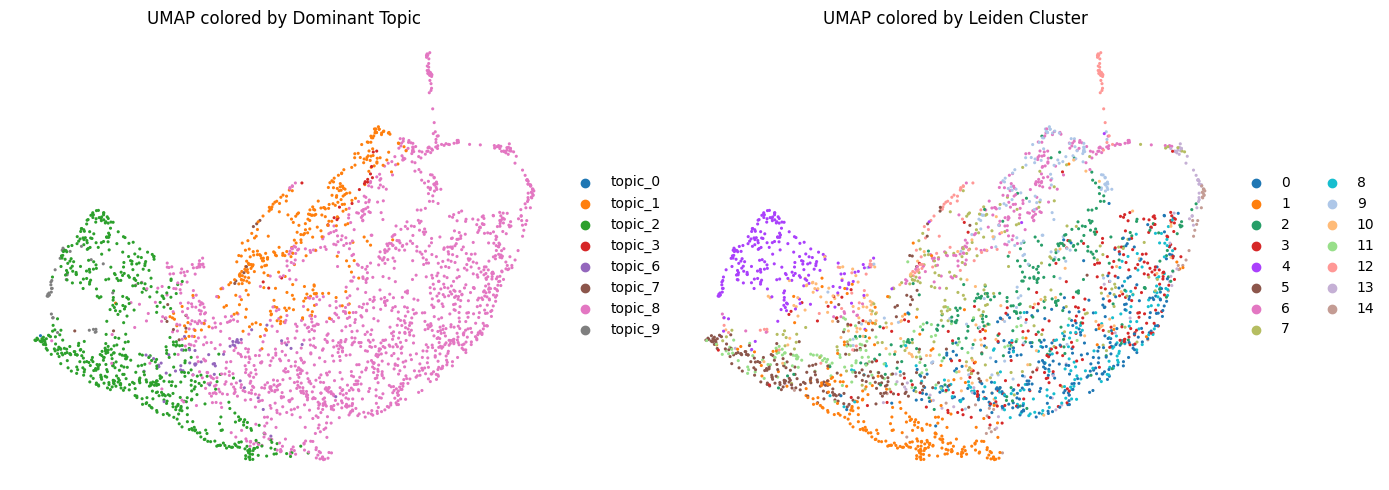

In [13]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

# 1) Get topic proportions per cell
theta = model.get_latent_representation(adata, batch_size=adata.n_obs)  # full batch
adata.obsm["X_topic"] = theta.values

# 2) Compute UMAP on topic space
sc.pp.neighbors(adata, use_rep="X_topic", n_neighbors=15, metric="cosine")
sc.tl.umap(adata, min_dist=0.3)

# 3) Get dominant topic per cell
adata.obs["dominant_topic"] = theta.idxmax(axis=1).values

# 4) Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Color by dominant topic
sc.pl.umap(
    adata, 
    color="dominant_topic", 
    ax=axes[0],
    frameon=False, 
    s=20,
    title="UMAP colored by Dominant Topic",
    show=False
)

# Right: Color by leiden (if available) or any other annotation
if "leiden" in adata.obs.columns:
    sc.pl.umap(
        adata,
        color="leiden",
        ax=axes[1],
        frameon=False,
        s=20,
        title="UMAP colored by Leiden Cluster",
        show=False
    )
else:
    # Compute leiden if not present
    sc.tl.leiden(adata, resolution=0.5)
    sc.pl.umap(
        adata,
        color="leiden",
        ax=axes[1],
        frameon=False,
        s=20,
        title="UMAP colored by Leiden Cluster",
        show=False
    )

plt.tight_layout()
plt.show()